# KMeans Clustering - Iris

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import warnings
warnings.filterwarnings("ignore")

# DATASET LOAD

In [2]:
name = "Iris"

data = load_iris()
X = data.data

In [4]:
df = pd.DataFrame(X)
print(f"Dataset Name: {name}")
print("Dataset Shape:", df.shape)
df.head()

Dataset Name: Iris
Dataset Shape: (150, 4)


,0,1,2,3
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


# Model Training using Different K values

In [6]:
k_values = range(2, 15)

wcss = []
sil_scores = []

for k in k_values:
    kmeans = KMeans(n_clusters=k, n_init=10, random_state=42)
    labels = kmeans.fit_predict(X)

    inertia = kmeans.inertia_
    sil = silhouette_score(X, labels)

    wcss.append(inertia)
    sil_scores.append(sil)

    # ✅ BOTH PRINTED TOGETHER (YOUR REQUEST)
    print(f"k={k}, inertia={round(inertia,2)}, silhouette={round(sil,4)}")

k=2, inertia=152.35, silhouette=0.681
k=3, inertia=78.85, silhouette=0.5528
k=4, inertia=57.23, silhouette=0.4981
k=5, inertia=46.46, silhouette=0.4912
k=6, inertia=39.04, silhouette=0.3648
k=7, inertia=34.31, silhouette=0.3543
k=8, inertia=30.13, silhouette=0.3487
k=9, inertia=28.29, silhouette=0.3125
k=10, inertia=25.97, silhouette=0.318
k=11, inertia=24.77, silhouette=0.3065
k=12, inertia=22.86, silhouette=0.2962
k=13, inertia=21.56, silhouette=0.3033
k=14, inertia=20.51, silhouette=0.2853


## Elbow Method and Silhouette Score

In [7]:
print("WCSS:", wcss)
print("\nSilhouette Scores:", sil_scores)

WCSS: [152.34795176035792, 78.85144142614601, 57.228473214285714, 46.46117267267268, 39.03998724608725, 34.30581529581529, 30.13244055461447, 28.290635241951037, 25.970929851803422, 24.765943419153945, 22.862825380759595, 21.557331281291805, 20.51483358798065]

Silhouette Scores: [0.6810461692117462, 0.5528190123564095, 0.49805050499728737, 0.49123997967644784, 0.36483400396700255, 0.3542978877198849, 0.3487345377219388, 0.312504408396839, 0.31796622568242083, 0.3064786140295812, 0.29616361654830853, 0.3032972323753288, 0.2852559016124137]


### Plots

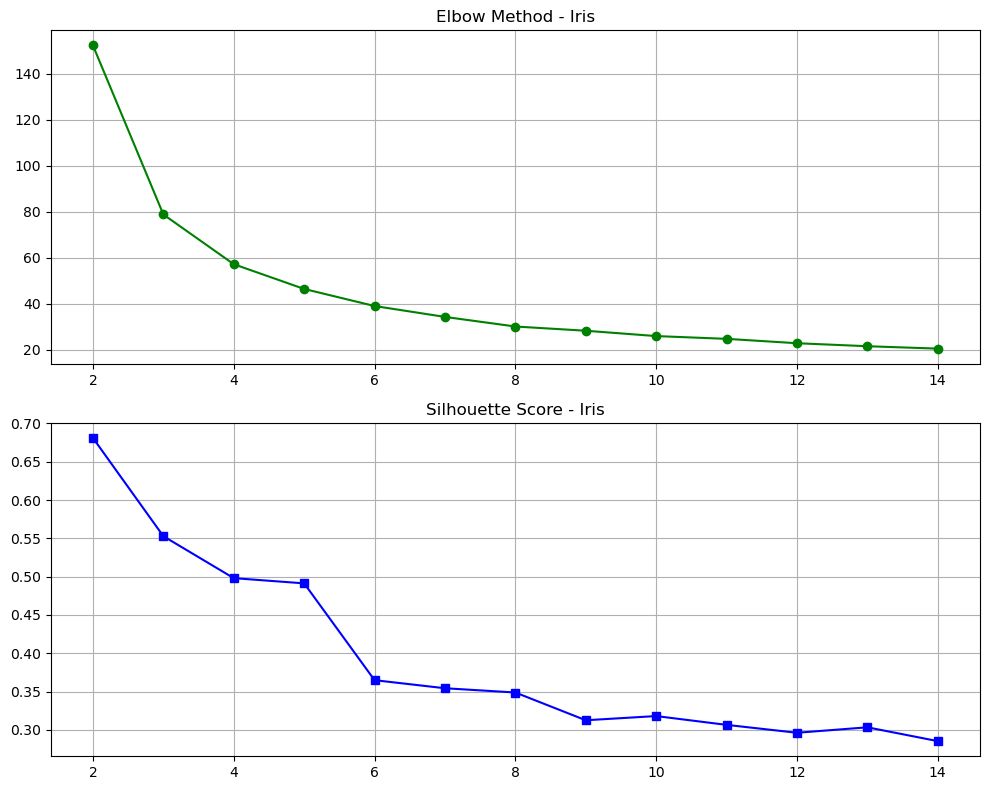

In [8]:
fig, axes = plt.subplots(2, 1, figsize=(10, 8))

axes[0].plot(k_values, wcss, marker="o", color="green")
axes[0].set_title(f"Elbow Method - {name}")
axes[0].grid(True)

axes[1].plot(k_values, sil_scores, marker="s", color="blue")
axes[1].set_title(f"Silhouette Score - {name}")
axes[1].grid(True)

plt.savefig("Elbow Method and Silhouette Score (Iris).png",dpi=100)
plt.tight_layout()
plt.show()

## Best K

In [9]:
best_k_wcss = list(k_values)[np.argmax(wcss)]
best_k_sil = list(k_values)[np.argmax(sil_scores)]

print(f"Best k (WCSS): {best_k_wcss}")
print(f"Best k (Silhouette): {best_k_sil}")

Best k (WCSS): 2
Best k (Silhouette): 2


### Model Training using Best K value

In [11]:
final_k = best_k_sil
kmeans = KMeans(n_clusters=final_k, n_init=10, random_state=42)
clusters = kmeans.fit_predict(X)

print(f"k={k}, inertia={round(kmeans.inertia_,2)}, silhouette={round(silhouette_score(X, clusters),4)}")

k=14, inertia=152.35, silhouette=0.681


#### Plot

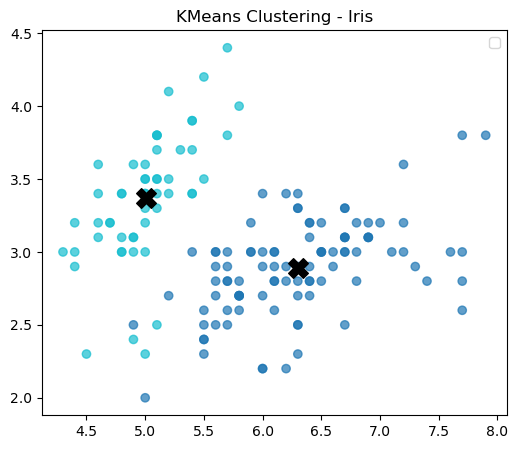

In [12]:
plt.figure(figsize=(6,5))
plt.scatter(X[:,0], X[:,1], c=clusters, cmap="tab10", alpha=0.7)
plt.scatter(kmeans.cluster_centers_[:,0],
            kmeans.cluster_centers_[:,1],
            s=200, marker="X", color="black")
plt.title(f"KMeans Clustering - {name}")
plt.savefig("KMeans Clustering (Iris).png",dpi=100)
plt.legend()
plt.show()